# CPSC 5860 Probabilistic Machine Learning, Spring 2026
## Srishti Bagchi, Yale University

## Set-up / Practice: Apply a flow-matching model on MNIST using a U-Net architecture

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 25.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 3.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 16.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.10MB/s]


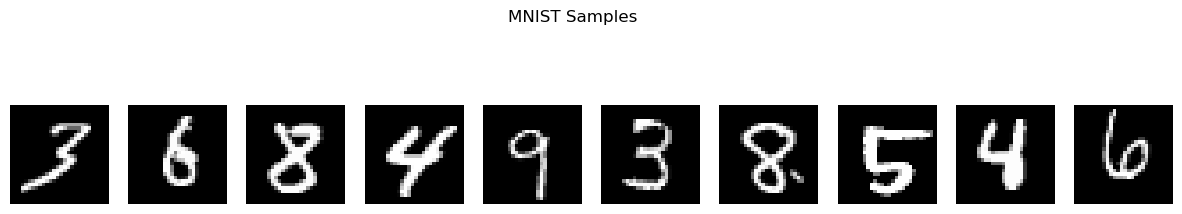

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchdiffeq import odeint

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=250, shuffle=True)

# Visualize some data
def show_images(images, title=""):
    fig, axes = plt.subplots(1, 10, figsize=(15, 3))
    for i in range(10):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_axis_off()
    plt.suptitle(title)
    plt.show()

# Get a batch and show
data_iter = iter(train_loader)
images, _ = next(data_iter)
show_images(images[:10], "MNIST Samples")

In [ ]:
# Define the UNet architecture for Flow Matching
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, class_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.class_proj = nn.Linear(class_dim, out_ch)
    
    def forward(self, x, t_emb, c_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = self.norm2(self.conv2(h))
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + self.class_proj(c_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + self.skip(x)
        return self.act(h)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, res_layers, time_dim, class_dim):
        super().__init__()
        self.res_blocks = nn.ModuleList([
            ResBlock(in_ch if i == 0 else out_ch, out_ch, time_dim, class_dim)
            for i in range(res_layers)
        ])
        self.down = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
    
    def forward(self, x, t_emb, c_emb):
        for res in self.res_blocks:
            x = res(x, t_emb, c_emb)
        x = self.down(x)
        return x

class UpBlock(nn.Module):
    def __init__(self, in_ch_to_up, out_ch_after_up, skip_ch, res_layers, time_dim, class_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch_to_up, out_ch_after_up, 4, 2, 1)
        res_in_ch = out_ch_after_up + skip_ch
        self.res_blocks = nn.ModuleList([
            ResBlock(res_in_ch if i == 0 else out_ch_after_up, out_ch_after_up, time_dim, class_dim)
            for i in range(res_layers)
        ])
    
    def forward(self, x, skip, t_emb, c_emb):
        x = self.up(x)
        # Interpolate skip to match x's spatial size
        skip = torch.nn.functional.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        for res in self.res_blocks:
            x = res(x, t_emb, c_emb)
        return x

class FlowMatchingUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, channels=[32, 64, 128], res_layers=2, 
                 time_dim=40, class_dim=40, num_classes=11):
        super().__init__()
        self.time_embed = nn.Linear(1, time_dim)
        self.class_embed = nn.Embedding(num_classes, class_dim)
        
        self.down_blocks = nn.ModuleList()
        ch = in_channels
        for c in channels:
            self.down_blocks.append(DownBlock(ch, c, res_layers, time_dim, class_dim))
            ch = c
        
        self.middle = ResBlock(ch, ch, time_dim, class_dim)
        
        self.up_blocks = nn.ModuleList()
        skip_channels = channels[::-1]  # [128, 64, 32]
        for i, c in enumerate(reversed(channels)):
            skip_ch = skip_channels[i]
            in_ch_to_up = ch
            out_ch_after_up = c
            self.up_blocks.append(UpBlock(in_ch_to_up, out_ch_after_up, skip_ch, res_layers, time_dim, class_dim))
            ch = c
        
        self.final = nn.Conv2d(ch, out_channels, 1)
    
    def forward(self, x, t, c):
        t_emb = self.time_embed(t)
        c_emb = self.class_embed(c)
        
        skips = []
        for down in self.down_blocks:
            x = down(x, t_emb, c_emb)
            skips.append(x)
        
        x = self.middle(x, t_emb, c_emb)
        
        for up in self.up_blocks:
            skip = skips.pop()
            x = up(x, skip, t_emb, c_emb)
        
        x = self.final(x)
        # Interpolate to original size 28x28
        x = torch.nn.functional.interpolate(x, size=(28, 28), mode='bilinear', align_corners=False)
        return x

model = FlowMatchingUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Flow matching loss
def flow_matching_loss(model, x0, x1, c):
    # x0: data, x1: noise (Gaussian)
    batch_size = x0.shape[0]
    t = torch.rand(batch_size, 1, device=device)
    
    # Linear interpolation
    t_expanded = t.unsqueeze(-1).unsqueeze(-1)  # (batch, 1, 1, 1)
    xt = (1 - t_expanded) * x0 + t_expanded * x1
    
    # Target velocity: x1 - x0
    target_v = x1 - x0
    
    # Predicted velocity
    pred_v = model(xt, t, c)
    
    loss = nn.MSELoss()(pred_v, target_v)
    return loss

print("Model defined and ready for training.")

Model defined and ready for training.


In [ ]:
# Training loop
num_epochs = 5000  # Total number of epochs
save_freq = 10  # Save checkpoint every save_freq epochs
early_stopping = True  # Toggle early stopping
patience = 100  # Number of epochs to wait for improvement
drop_prob = 0.1  # Probability of dropping the class

best_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (x0, labels) in enumerate(train_loader):
        x0 = x0.to(device)
        labels = labels.to(device)
        batch_size = x0.shape[0]
        
        # Sample noise
        x1 = torch.randn_like(x0)
        
        # CFG: with probability drop_prob, set class to null (10)
        c = labels.clone()
        mask = torch.rand(batch_size, device=device) < drop_prob
        c[mask] = 10
        
        loss = flow_matching_loss(model, x0, x1, c)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} completed, Average Loss: {avg_loss:.4f}")
    
    # Check for improvement
    if avg_loss < best_loss:
        best_loss = avg_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(model.state_dict(), 'checkpoints/best_flow_matching_model.pth')
    else:
        epochs_no_improve += 1
    
    # Save checkpoint every save_freq epochs
    if (epoch + 1) % save_freq == 0:
        torch.save(model.state_dict(), f'checkpoints/flow_matching_model_epoch_{epoch+1}.pth')
        print(f"Checkpoint saved at epoch {epoch+1}")
    
    # Early stopping
    if early_stopping and epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}, no improvement for {patience} epochs")
        break

print("Training completed!")

# Save the final model
torch.save(model.state_dict(), 'checkpoints/flow_matching_model.pth')
print("Final model saved to checkpoints/flow_matching_model.pth")

Model loaded from flow_matching_model.pth


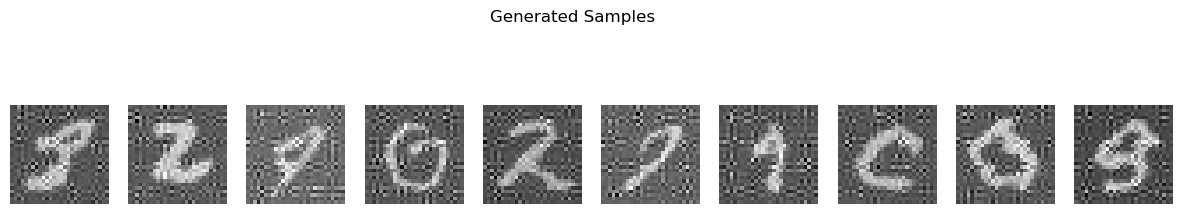

In [ ]:
# Sampling function
def sample_flow_matching(model, num_samples=10, steps=100):
    model.eval()
    with torch.no_grad():
        # Start from noise
        x = torch.randn(num_samples, 1, 28, 28, device=device)
        
        # Time points from 1 to 0
        t_span = torch.linspace(1, 0, steps, device=device)
        
        # Class: unconditional (null class 10)
        c = torch.full((num_samples,), 10, dtype=torch.long, device=device)
        
        # Define the ODE function
        def ode_func(t, x):
            t_tensor = t.expand(x.shape[0], 1)
            return model(x, t_tensor, c).view(x.shape)
        
        # Solve ODE
        traj = odeint(ode_func, x, t_span, method='dopri5')
        
        # Get final samples
        samples = traj[-1]
        
        return samples

# Load the trained model (best if early stopping was used, else final)
model_path = 'checkpoints/best_flow_matching_model.pth' if early_stopping else 'checkpoints/flow_matching_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
print(f"Model loaded from {model_path}")

# Generate samples
samples = sample_flow_matching(model, num_samples=10)
show_images(samples.cpu(), "Generated Samples")

## Experiment 1: Generalization-Memorization on a Synthetic Spiral Dataset

In [ ]:
import numpy as np
from numpy import pi
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
import os
from tqdm import tqdm
from scipy.stats import wasserstein_distance_nd


log_dir = "logs/spiral"
plot_dir = "plots/spiral"
os.makedirs(log_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

class FlowMatchingMLP(nn.Module):
    def __init__(self, dim=2, hidden_dim=512, time_dim=64, num_classes=2, class_dim=32):
        super().__init__()
        self.time_proj = nn.Linear(1, time_dim)
        self.class_emb = nn.Embedding(num_classes, class_dim)
        self.net = nn.Sequential(
            nn.Linear(dim + time_dim + class_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x, t, c=None):
        t_emb = self.time_proj(t)
        if c is None:
            c_emb = torch.zeros(x.shape[0], self.class_emb.embedding_dim, device=x.device, dtype=x.dtype)
        else:
            c = c.view(-1).long()
            c_emb = self.class_emb(c)
        x_cond = torch.cat([x, t_emb, c_emb], dim=1)
        return self.net(x_cond)


def flow_matching_loss_2d(model, x0):
    batch_size = x0.shape[0]
    t = torch.rand(batch_size, 1, device=device)
    x1 = torch.randn_like(x0)
    xt = (1 - t) * x0 + t * x1
    target_v = x1 - x0
    pred_v = model(xt, t)
    return nn.MSELoss()(pred_v, target_v)


def sample_spiral_flow(model, num_samples=400, steps=200, class_label=None):
    model.eval()
    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        t_span = torch.linspace(1, 0, steps, device=device)

        if class_label is None:
            c = None
        else:
            c = torch.full((num_samples,), class_label, device=device, dtype=torch.long)

        def ode_func(t, x):
            t_tensor = t.expand(x.shape[0], 1)
            return model(x, t_tensor, c)

        traj = odeint(ode_func, x, t_span, method='dopri5')
        return traj


def visualize_vector_field(model, mean_spiral, std_spiral, data_range, t=0.5, class_label=None, grid_size=20):
    x_min, x_max, y_min, y_max = data_range
    xs = np.linspace(x_min, x_max, grid_size)
    ys = np.linspace(y_min, y_max, grid_size)
    xx, yy = np.meshgrid(xs, ys)
    points = np.stack([xx.ravel(), yy.ravel()], axis=-1).astype(np.float32)
    points_norm = (torch.from_numpy(points).to(device) - mean_spiral) / std_spiral
    t_tensor = torch.full((points_norm.shape[0], 1), t, device=device)
    if class_label is None:
        c = None
    else:
        c = torch.full((points_norm.shape[0],), class_label, device=device, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        vec = model(points_norm, t_tensor, c).cpu().numpy()
    return xx, yy, vec.reshape(xx.shape + (2,))


def matrix_sqrt(mat):
    vals, vecs = np.linalg.eigh(mat)
    vals = np.clip(vals, a_min=0, a_max=None)
    return vecs @ np.diag(np.sqrt(vals)) @ vecs.T

# FID calculation according to Heusel, Martin et al. “GANs Trained by a Two Time-Scale Update Rule 
# Converge to a Local Nash Equilibrium.” Neural Information Processing Systems (2017).
def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    diff = np.sum((mu1 - mu2) ** 2)
    covmean = matrix_sqrt(sigma1.dot(sigma2))
    if not np.isfinite(covmean).all():
        sigma1 += np.eye(sigma1.shape[0]) * eps
        sigma2 += np.eye(sigma2.shape[0]) * eps
        covmean = matrix_sqrt(sigma1.dot(sigma2))
    return diff + np.trace(sigma1 + sigma2 - 2 * covmean)


# Calculate Wasserstein distance between samples and reference 
def calculate_wasserstein_distance(samples, reference):
    dists = []
    for i in range(samples.shape[1]):
        dists.append(wasserstein_distance_nd(samples[:, i], reference[:, i]))
    return np.mean(dists)


def calculate_fid(samples, reference):
    mu1 = np.mean(samples, axis=0)
    mu2 = np.mean(reference, axis=0)
    sigma1 = np.cov(samples, rowvar=False)
    sigma2 = np.cov(reference, rowvar=False)
    return frechet_distance(mu1, sigma1, mu2, sigma2)


# Calculate memorization between samples and original dataset
# A datapoint x_t is considered memorized if \mathbb{E}_{x_t}[\frac{\|x_t - a_1\|_2}{\|x_t - a_2\|_2}] < 0.50
# where a_1 and a_2 are the nearest and second nearest neighbors in the training dataset respectively
def calculate_memorization(samples, original_data):
    nbrs = NearestNeighbors(n_neighbors=2).fit(original_data)
    distances, indices = nbrs.kneighbors(samples)
    ratios = distances[:, 0] / (distances[:, 1] + 1e-6)  # Avoid division by zero
    memorized_count = np.sum(ratios < 0.50)
    return memorized_count, len(samples)


def evaluate_loss(model, x):
    model.eval()
    with torch.no_grad():
        return flow_matching_loss_2d(model, x).item()


In [ ]:
# Experiment Grid
experiments = [
    # {'N': 8, 'hidden_dim': 512},
    # {'N': 16, 'hidden_dim': 512},
    # {'N': 32, 'hidden_dim': 512},
    # {'N': 64, 'hidden_dim': 512},
    # {'N': 128, 'hidden_dim': 512},
    # {'N': 256, 'hidden_dim': 512},
    # {'N': 512, 'hidden_dim': 512},
    # {'N': 1024, 'hidden_dim': 512},
    # {'N': 1024, 'hidden_dim': 512},
    {'N': 128, 'hidden_dim': 8},
    {'N': 128, 'hidden_dim': 16},
    {'N': 128, 'hidden_dim': 32},
    {'N': 128, 'hidden_dim': 64},
    {'N': 128, 'hidden_dim': 128},
    {'N': 128, 'hidden_dim': 256},
    {'N': 128, 'hidden_dim': 512},
]
num_epochs = int(1e5)  # max epochs for training each experiment
sample_size = 200  # Sample size for evaluation

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Main Experimental Loop
for exp in tqdm(experiments, desc="Experiments"):

    # Make the synthetic spiral dataset
    N = exp['N']  # points per class
    theta = np.sqrt(np.random.rand(N)) * 2 * pi
    # Class A
    r_a = 2 * theta + pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    x_a = data_a + np.random.randn(N, 2)
    # Class B
    r_b = -2 * theta - pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    x_b = data_b + np.random.randn(N, 2)

    # Combine and shuffle
    spiral_points = np.vstack([x_a, x_b]).astype(np.float32)
    train_points, test_points = train_test_split(spiral_points, test_size=0.25, random_state=42)

    # Normalize using training distribution
    train_tensor = torch.from_numpy(train_points).to(device)
    mean_spiral = train_tensor.mean(0, keepdim=True)
    std_spiral = train_tensor.std(0, unbiased=False, keepdim=True) + 1e-6
    train_norm = (train_tensor - mean_spiral) / std_spiral
    test_tensor = torch.from_numpy(test_points).to(device)
    test_norm = (test_tensor - mean_spiral) / std_spiral

    train_loader = DataLoader(train_norm, batch_size=len(train_norm), shuffle=True)  # uses whole batch training

    model_spiral = FlowMatchingMLP(hidden_dim=exp['hidden_dim']).to(device)
    optimizer_spiral = optim.Adam(model_spiral.parameters(), lr=1e-3)

    epoch_metrics = []
    train_raw = train_points
    test_raw = test_points


    # Main training loop
    for epoch in tqdm(range(num_epochs)):
        model_spiral.train()
        total_loss = 0.0
        for x_batch in train_loader:
            x_batch = x_batch.to(device)
            loss = flow_matching_loss_2d(model_spiral, x_batch)

            optimizer_spiral.zero_grad()
            loss.backward()
            optimizer_spiral.step()

            total_loss += loss.item()

        # record metrics every few epochs
        if (epoch + 1) % 100 == 0 or epoch == 0:
            # calculate training and test loss for the epoch
            avg_train_loss = total_loss / len(train_loader)
            test_loss = evaluate_loss(model_spiral, test_norm)

            # test sample generation
            samples_traj_norm = sample_spiral_flow(model_spiral, num_samples=sample_size, class_label=None)
            samples_norm = samples_traj_norm[-1]
            samples = (samples_norm * std_spiral + mean_spiral).cpu().numpy()
            initial_norm = samples_traj_norm[0]
            initial = (initial_norm * std_spiral + mean_spiral).cpu().numpy()

            # calculate memorization rate and FID (generalization metric) of generation samples
            memorized_count, total_samples = calculate_memorization(samples, train_raw)
            f_mem = memorized_count / total_samples
            fid = calculate_wasserstein_distance(samples, test_raw)

            epoch_metrics.append({
                'epoch': epoch + 1,
                'train_loss': avg_train_loss,
                'test_loss': test_loss,
                'f_mem': f_mem,
                'fid': fid,
            })

            log_path = os.path.join(log_dir, f"spiral_N{N}_hidden{exp['hidden_dim']}.txt")
            msg = (
                f"Epoch {epoch+1}/{num_epochs} "
                f"| train_loss={avg_train_loss:.4f} "
                f"| test_loss={test_loss:.4f} "
                f"| f_mem={f_mem:.4f} "
                f"| fid={fid:.4f}\n"
            )
            with open(log_path, "a+") as log_file:
                log_file.write(msg)
    # end of training loop

    # save metrics
    metrics_path = os.path.join(log_dir, f"metrics_N{N}_hidden{exp['hidden_dim']}.npz")
    np.savez(metrics_path, **{k: np.array([m[k] for m in epoch_metrics]) for k in epoch_metrics[0]})

    # save train and test loss plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot([m['epoch'] for m in epoch_metrics], [m['train_loss'] for m in epoch_metrics], label='Train Loss')
    plt.plot([m['epoch'] for m in epoch_metrics], [m['test_loss'] for m in epoch_metrics], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'N={N}, hidden={exp["hidden_dim"]} Loss')

    # save memorization and FID plot
    ax1 = plt.subplot(1, 2, 2)
    ax2 = ax1.twinx()
    ax1.plot([m['epoch'] for m in epoch_metrics], [m['f_mem'] for m in epoch_metrics], label='Memorization', color='C0')
    ax2.plot([m['epoch'] for m in epoch_metrics], [m['fid'] for m in epoch_metrics], label='FID', color='C1')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Memorization', color='C0')
    ax2.set_ylabel('FID', color='C1')
    ax1.tick_params(axis='y', labelcolor='C0')
    ax2.tick_params(axis='y', labelcolor='C1')
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    ax1.set_title(f'N={N}, hidden={exp["hidden_dim"]} Eval Metrics')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'metrics_N{N}_hidden{exp["hidden_dim"]}.png'))
    plt.close()

    # save generated samples plot
    plt.figure(figsize=(6, 6))
    plt.scatter(train_raw[:, 0], train_raw[:, 1], c='C0', s=8, alpha=0.4, label='Train Data')
    traj_np = samples_traj_norm.cpu().numpy()
    traj_np = traj_np * std_spiral.cpu().numpy() + mean_spiral.cpu().numpy()
    for i in range(traj_np.shape[1]):
        plt.plot(traj_np[:, i, 0], traj_np[:, i, 1], color='grey', alpha=0.2, linewidth=0.7)
    initial_points = traj_np[0]
    final_points = traj_np[-1]
    plt.scatter(initial_points[:, 0], initial_points[:, 1], c='grey', s=10, alpha=0.6, marker='x', label='Initial Samples')
    plt.scatter(final_points[:, 0], final_points[:, 1], c='C2', s=12, alpha=0.6, label='Generated Samples')
    plt.title(f'Generated Trajectories vs Spiral (N={N}, hidden={exp["hidden_dim"]})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig(os.path.join(plot_dir, f'generated_N{N}_hidden{exp["hidden_dim"]}.png'))
    plt.close()

    # visualize vector field at an arbitrary timestamp
    t_vis = 0.8
    data_range = (
        train_raw[:, 0].min() - 1.0,
        train_raw[:, 0].max() + 1.0,
        train_raw[:, 1].min() - 1.0,
        train_raw[:, 1].max() + 1.0,
    )
    xx, yy, vf = visualize_vector_field(model_spiral, mean_spiral, std_spiral, data_range, t=t_vis, class_label=None, grid_size=20)
    plt.figure(figsize=(6, 6))
    plt.quiver(xx, yy, vf[..., 0], vf[..., 1], color='grey', alpha=0.8, scale=30, width=0.002)
    plt.scatter(train_raw[:, 0], train_raw[:, 1], c='C0', s=8, alpha=0.4, label='Train Data')
    plt.title(f'Vector Field at t={t_vis:.2f} (N={N}, hidden={exp["hidden_dim"]})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig(os.path.join(plot_dir, f'vector_field_t{int(t_vis*100)}_N{N}_hidden{exp["hidden_dim"]}.png'))
    plt.close()

print("All experiments completed!")

Using device: cuda


Experiments:  57%|█████▋    | 4/7 [32:31<24:46, 495.35s/it]

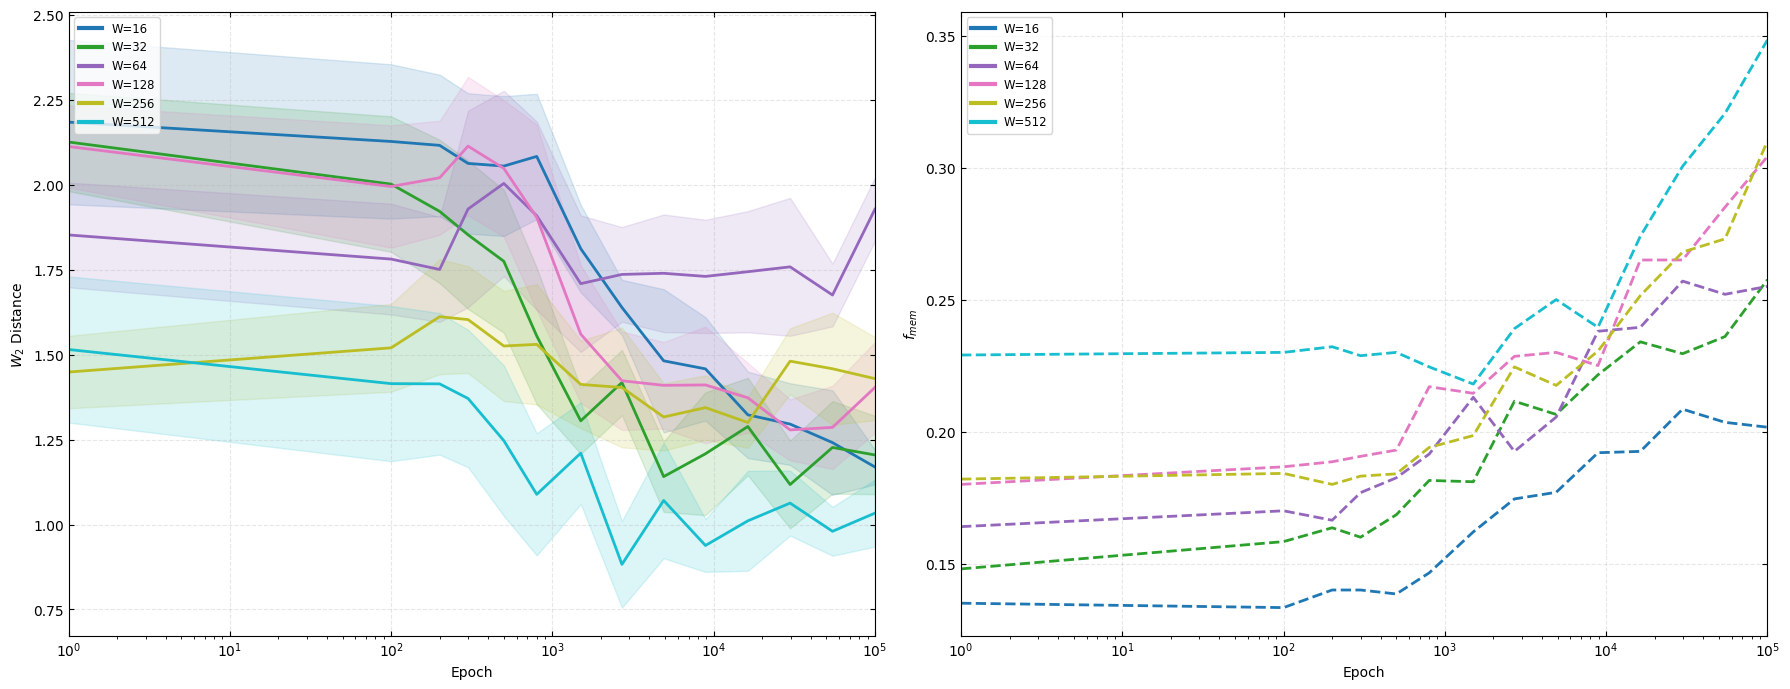

In [1]:
# Metrics comparison plots for experiments with a constant hidden dimension
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

metrics_dir = "logs/spiral"
pattern = os.path.join(metrics_dir, "metrics_N*_hidden*.npz")
metric_files = sorted(glob.glob(pattern))

rows = []
for filepath in metric_files:
    filename = os.path.basename(filepath)
    match = re.match(r"metrics_N(?P<N>\d+)_hidden(?P<hidden>\d+)\.npz", filename)
    if not match:
        continue
    N = int(match.group("N"))
    hidden = int(match.group("hidden"))
    data = np.load(filepath)
    epochs = data["epoch"]
    train_loss = data["train_loss"]
    test_loss = data["test_loss"]
    f_mem = data["f_mem"]
    fid = data["fid"]
    for i, epoch in enumerate(epochs):
        rows.append({
            "N": N,
            "hidden": hidden,
            "epoch": int(epoch),
            "train_loss": float(train_loss[i]),
            "test_loss": float(test_loss[i]),
            "f_mem": float(f_mem[i]),
            "fid": float(fid[i]),
        })

if len(rows) == 0:
    raise RuntimeError(f"No metric files found in {metrics_dir} matching pattern {pattern}")

metrics_df = pd.DataFrame(rows)

# Choose the fixed axis and series to compare
# Option A: Fix a hidden width and compare several N values
chosen_hidden_dim = None # 512
selected_N = [16, 32, 64, 128, 256, 512, 1024]

# Option B: Fix an N value and compare several hidden widths
chosen_N =  128  
selected_hidden_dims = [16, 32, 64, 128, 256, 512]

min_epoch = 0
mem_gen_window = 10  # increase this to make smoothing stronger
loss_window = 50

if chosen_N is not None:
    subset = metrics_df[metrics_df["N"] == chosen_N].copy()
    if selected_hidden_dims is not None:
        subset = subset[subset["hidden"].isin(selected_hidden_dims)].copy()
    if subset.empty:
        available_hidden = sorted(metrics_df.loc[metrics_df['N'] == chosen_N, 'hidden'].unique())
        raise ValueError(
            f"No experiments found for N={chosen_N}. Available hidden dims for this N: {available_hidden}"
        )
    group_key = "hidden"
    legend_prefix = "W"
    title_base = f"N={chosen_N}"
else:
    subset = metrics_df[metrics_df["hidden"] == chosen_hidden_dim].copy()
    if selected_N is not None:
        subset = subset[subset["N"].isin(selected_N)].copy()
    if subset.empty:
        available_N = sorted(metrics_df.loc[metrics_df['hidden'] == chosen_hidden_dim, 'N'].unique())
        raise ValueError(
            f"No experiments found for hidden_dim={chosen_hidden_dim}. Available N values for this hidden width: {available_N}"
        )
    group_key = "N"
    legend_prefix = "N"
    title_base = f"hidden={chosen_hidden_dim}"

# Sorting and smoothing helper
subset = subset.sort_values([group_key, "epoch"]).reset_index(drop=True)

def smooth_series(series, window=10):
    return series.rolling(window=window, min_periods=1, center=True).mean()

def smooth_std(series, window=10):
    return series.rolling(window=window, min_periods=1, center=True).std()

# Select log-spaced epoch points for plotting to keep density consistent on a log axis
# (This avoids heavy overplotting near the left side of the log-scaled x-axis.)
def select_log_spaced_indices(x_values, num_points=20):
    x_arr = np.asarray(x_values)
    if len(x_arr) <= num_points:
        return np.arange(len(x_arr))
    target_epochs = np.unique(np.round(np.logspace(np.log10(x_arr[0]), np.log10(x_arr[-1]), num=num_points)).astype(int))
    indices = np.searchsorted(x_arr, target_epochs)
    indices = np.clip(indices, 0, len(x_arr) - 1)
    return np.unique(indices)

# Create a 1x2 figure for the primary comparison plots
fig, (ax_top_left, ax_top_right) = plt.subplots(1, 2, figsize=(18, 7), sharex=False)
colors = plt.cm.tab10(np.linspace(0, 1, subset[group_key].nunique()))

if group_key == 'N':
    # Top-left plot: FID on left y-axis, f_mem on right y-axis
    ax_fid = ax_top_left
    ax_mem = ax_top_left.twinx()

    for idx, (group_value, group) in enumerate(subset.groupby(group_key)):
        group = group.sort_values('epoch')
        x = group['epoch']
        idxs = select_log_spaced_indices(x)
        x_plot = x.iloc[idxs]
        fid_smoothed = smooth_series(group['fid'], window=mem_gen_window).iloc[idxs]
        fid_std = smooth_std(group['fid']).iloc[idxs]
        fmem_smoothed = smooth_series(group['f_mem'], window=mem_gen_window).iloc[idxs]
        color = colors[idx]

        ax_fid.plot(x_plot, fid_smoothed, label=f'$W_2$ {legend_prefix}={group_value}', color=color, linewidth=2)
        ax_fid.fill_between(x_plot, fid_smoothed - fid_std * 0.5, fid_smoothed + fid_std * 0.5, color=color, alpha=0.15)
        ax_mem.plot(x_plot, fmem_smoothed, label=f'f_mem {legend_prefix}={group_value}', color=color, linestyle='--', linewidth=2)

    min_epoch_plot = max(min_epoch, subset['epoch'].min())
    max_epoch_plot = subset['epoch'].max()
    ax_fid.set_xscale('log')
    ax_fid.set_xlim(min_epoch_plot, max_epoch_plot)
    ax_fid.set_xlabel('Epoch')
    ax_fid.set_ylabel('$W_2$ Distance')
    ax_fid.tick_params(direction='in', top=True, right=True, bottom=True, left=True)
    ax_mem.set_ylabel('$f_{mem}$')
    ax_mem.tick_params(direction='in', top=True, right=True, bottom=True, left=True)

    color_handles = [Line2D([0], [0], color=colors[idx], lw=3) for idx, group_value in enumerate(sorted(subset[group_key].unique()))]
    color_labels = [f'{legend_prefix}={group_value}' for group_value in sorted(subset[group_key].unique())]
    style_handles = [Line2D([0], [0], color='black', lw=2, linestyle='-'), Line2D([0], [0], color='black', lw=2, linestyle='--')]
    style_labels = ['$W_2$ Distance', '$f_{mem}$']
    legend1 = ax_top_left.legend(color_handles, color_labels, loc='upper left', fontsize='small', borderaxespad=0.0)
    ax_top_left.add_artist(legend1)
    ax_top_left.legend(style_handles, style_labels, loc='lower left', fontsize='small', borderaxespad=0.0)

    # Top-right plot: train/test loss vs epoch
    for idx, (group_value, group) in enumerate(subset.groupby(group_key)):
        group = group.sort_values('epoch')
        x = group['epoch']
        idxs = select_log_spaced_indices(x)
        x_plot = x.iloc[idxs]
        train_smoothed = smooth_series(group['train_loss'], window=loss_window).iloc[idxs]
        test_smoothed = smooth_series(group['test_loss'], window=loss_window).iloc[idxs]
        color = colors[idx]

        ax_top_right.set_ylabel('Loss')

        ax_top_right.plot(x_plot, train_smoothed, color=color, linewidth=2)
        ax_top_right.plot(x_plot, test_smoothed, color=color, linestyle='--', linewidth=2)

    legend2_handles = [Line2D([0], [0], color=colors[idx], lw=3) for idx, group_value in enumerate(sorted(subset[group_key].unique()))]
    legend2_labels = [f'{legend_prefix}={group_value}' for group_value in sorted(subset[group_key].unique())]
    style_handles_rt = [Line2D([0], [0], color='black', lw=2, linestyle='-'), Line2D([0], [0], color='black', lw=2, linestyle='--')]
    style_labels_rt = ['$\\mathcal{L}_{train}$', '$\\mathcal{L}_{test}$']
    legend2 = ax_top_right.legend(legend2_handles, legend2_labels, loc='upper left', fontsize='small', borderaxespad=1.0)
    ax_top_right.add_artist(legend2)
    ax_top_right.legend(style_handles_rt, style_labels_rt, loc='lower left', fontsize='small', borderaxespad=1.0)
    ax_top_right.set_xlim(min_epoch_plot, max_epoch_plot)
    ax_top_right.set_xscale('log')
    ax_top_right.set_xlabel('Epoch')
    ax_top_right.tick_params(direction='in', top=True, right=True, bottom=True, left=True)
else:
    # For W variation, use two separate plots: FID on the left, f_mem on the right
    for idx, (group_value, group) in enumerate(subset.groupby(group_key)):
        group = group.sort_values('epoch')
        x = group['epoch']
        idxs = select_log_spaced_indices(x)
        x_plot = x.iloc[idxs]
        fid_smoothed = smooth_series(group['fid'], window=mem_gen_window).iloc[idxs]
        fid_std = smooth_std(group['fid']).iloc[idxs]
        fmem_smoothed = smooth_series(group['f_mem'], window=mem_gen_window).iloc[idxs]
        color = colors[idx]

        ax_top_left.plot(x_plot, fid_smoothed, label=f'FID {legend_prefix}={group_value}', color=color, linewidth=2)
        ax_top_left.fill_between(x_plot, fid_smoothed - fid_std * 0.5, fid_smoothed + fid_std * 0.5, color=color, alpha=0.15)
        ax_top_right.plot(x_plot, fmem_smoothed, label=f'f_mem {legend_prefix}={group_value}', color=color, linestyle='--', linewidth=2)

    min_epoch_plot = max(min_epoch, subset['epoch'].min())
    max_epoch_plot = subset['epoch'].max()
    ax_top_left.set_xscale('log')
    ax_top_left.set_xlim(min_epoch_plot, max_epoch_plot)
    ax_top_left.set_xlabel('Epoch')
    ax_top_left.set_ylabel('$W_2$ Distance')
    ax_top_left.grid(True, linestyle='--', alpha=0.3)
    ax_top_left.tick_params(direction='in', top=True, right=True, bottom=True, left=True)

    ax_top_right.set_xscale('log')
    ax_top_right.set_xlim(min_epoch_plot, max_epoch_plot)
    ax_top_right.set_xlabel('Epoch')
    ax_top_right.set_ylabel('$f_{mem}$')
    ax_top_right.grid(True, linestyle='--', alpha=0.3)
    ax_top_right.tick_params(direction='in', top=True, right=True, bottom=True, left=True)

    legend_left_handles = [Line2D([0], [0], color=colors[idx], lw=3) for idx, group_value in enumerate(sorted(subset[group_key].unique()))]
    legend_left_labels = [f'{legend_prefix}={group_value}' for group_value in sorted(subset[group_key].unique())]
    ax_top_left.legend(legend_left_handles, legend_left_labels, loc='upper left', fontsize='small', borderaxespad=0.5)
    ax_top_right.legend(legend_left_handles, legend_left_labels, loc='upper left', fontsize='small', borderaxespad=0.5)


plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


## Empirical Convergence Rate of Flow-Matching on a Target Gaussian

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


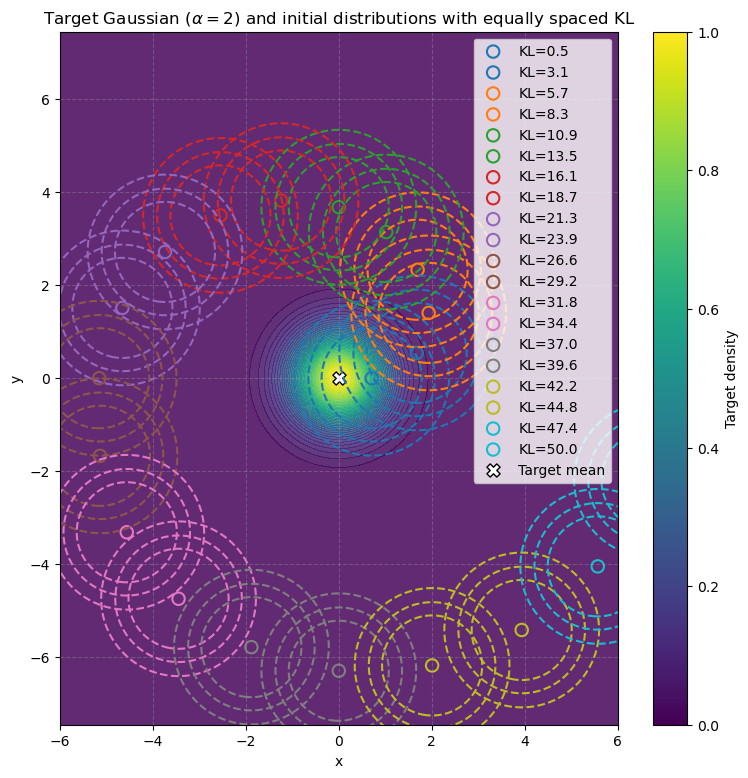

In [1]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 2.0

target_mean = np.zeros(2)
target_cov = np.eye(2) / alpha
target_cov_inv = np.linalg.inv(target_cov)

def gaussian_density(points, mean, cov, cov_inv=None):
    if cov_inv is None:
        cov_inv = np.linalg.inv(cov)
    diff = points - mean
    exponent = -0.5 * np.einsum('...i,ij,...j', diff, cov_inv, diff)
    normalization = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))
    return normalization * np.exp(exponent)

# Target distribution (strongly log-concave Gaussian)
grid = np.linspace(-8, 8, 500)
xx, yy = np.meshgrid(grid, grid)
xy = np.stack([xx, yy], axis=-1)
target_density = gaussian_density(xy, target_mean, target_cov, target_cov_inv)

# Create starting distributions with equally spaced KL divergence values relative to the target
num_starts = 20
min_kl = 0.5
max_kl = 50.0
starting_kl = np.linspace(min_kl, max_kl, num_starts)
angles = np.linspace(0, 2 * np.pi, len(starting_kl), endpoint=False)
starting_means = [
    np.sqrt(kl) * np.array([np.cos(theta), np.sin(theta)])
    for kl, theta in zip(starting_kl, angles)
]
starting_cov = target_cov

plt.figure(figsize=(9, 9))
plt.contourf(xx, yy, target_density, levels=40, cmap='viridis', alpha=0.85)
colors = plt.cm.tab10(np.linspace(0, 1, len(starting_means)))
for mean, kl, color in zip(starting_means, starting_kl, colors):
    start_density = gaussian_density(xy, mean, starting_cov, target_cov_inv)
    plt.contour(xx, yy, start_density, levels=[0.02, 0.05, 0.10], colors=[color], linestyles='--')
    plt.scatter(mean[0], mean[1], s=80, edgecolor=color, facecolor='none', linewidth=1.5, label=f'KL={kl:.1f}')

plt.scatter(0, 0, color='white', edgecolor='black', s=90, marker='X', label='Target mean')
plt.title(r'Target Gaussian ($\alpha=2$) and initial distributions with equally spaced KL')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.grid(True, linestyle='--', alpha=0.3)
plt.colorbar(label='Target density')
plt.legend(loc='upper right')
plt.show()

start KL=0.50, norm=0.707, epochs=20, final_error=0.0120
start KL=5.74, norm=2.395, epochs=80, final_error=0.0519
start KL=10.97, norm=3.313, epochs=120, final_error=0.1176
start KL=16.21, norm=4.026, epochs=120, final_error=0.0925
start KL=21.45, norm=4.631, epochs=220, final_error=0.0984
start KL=26.68, norm=5.166, epochs=220, final_error=0.1084
start KL=31.92, norm=5.650, epochs=220, final_error=0.1180
start KL=37.16, norm=6.096, epochs=160, final_error=0.0780
start KL=42.39, norm=6.511, epochs=140, final_error=0.0913
start KL=47.63, norm=6.902, epochs=160, final_error=0.0930
start KL=52.87, norm=7.271, epochs=260, final_error=0.1132
start KL=58.11, norm=7.623, epochs=240, final_error=0.1065
start KL=63.34, norm=7.959, epochs=220, final_error=0.1047
start KL=68.58, norm=8.281, epochs=240, final_error=0.0903
start KL=73.82, norm=8.592, epochs=300, final_error=0.1046
start KL=79.05, norm=8.891, epochs=200, final_error=0.0827
start KL=84.29, norm=9.181, epochs=240, final_error=0.1196
s

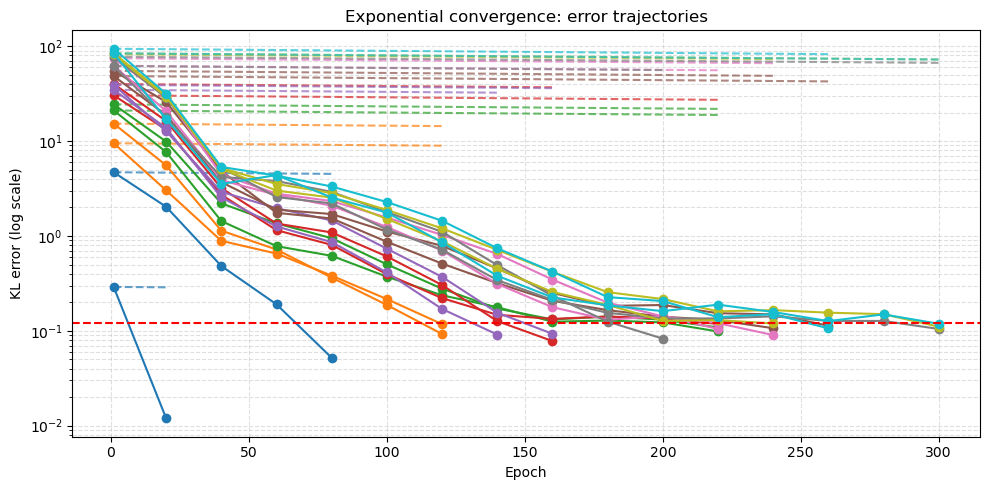

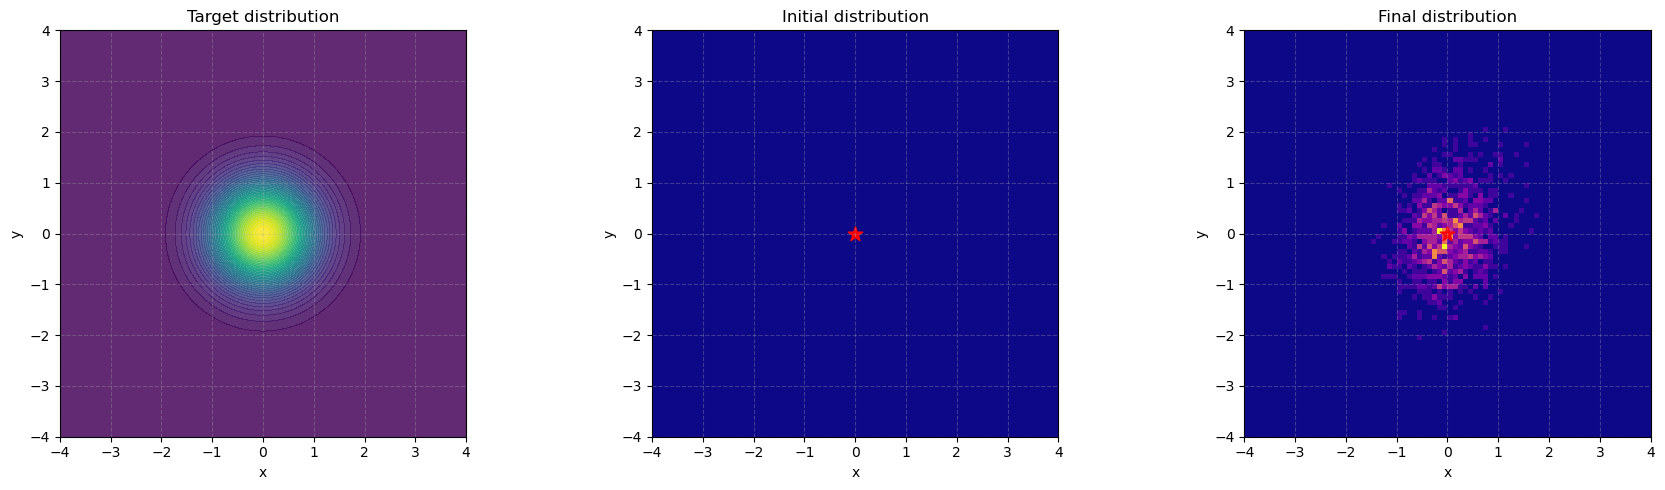

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

np.random.seed(0)
torch.manual_seed(0)

# Simple velocity field learner for flow matching from each initialization to the target Gaussian.
class VelocityMLP(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt)


def sample_gaussian(mean, cov, n_samples):
    return np.random.multivariate_normal(mean, cov, size=n_samples).astype(np.float32)


def integrate_flow(model, x0, steps=20):
    x = x0.clone()
    dt = 1.0 / steps
    for step in range(steps):
        t = torch.full((x.shape[0], 1), step * dt, dtype=x.dtype, device=x.device)
        v = model(x, t)
        x = x + dt * v
    return x


def gaussian_kl(mean_q, cov_q, mean_p, cov_p, eps=1e-6):
    cov_q = cov_q + np.eye(cov_q.shape[0]) * eps
    cov_p = cov_p + np.eye(cov_p.shape[0]) * eps

    k = mean_q.shape[0]
    diff = mean_p - mean_q

    inv_cov_p = np.linalg.inv(cov_p)
    trace_term = np.trace(inv_cov_p @ cov_q)
    mahalanobis = diff.T @ inv_cov_p @ diff

    sign_q, logdet_q = np.linalg.slogdet(cov_q)
    sign_p, logdet_p = np.linalg.slogdet(cov_p)
    logdet_term = logdet_p - logdet_q

    return 0.5 * (trace_term + mahalanobis - k + logdet_term)

# Calculate the KL divergence between the distribution of samples and the target Gaussian
def distribution_error(samples, target_mean, target_cov):
    mu = samples.mean(axis=0)
    cov = np.cov(samples, rowvar=False)
    return gaussian_kl(mu, cov, target_mean, target_cov)


target_mean = np.zeros(2, dtype=np.float32)
target_cov = np.eye(2, dtype=np.float32) / alpha

starting_kl = np.linspace(0.5, 100, 20)
starting_means = [np.sqrt(2 * kl / alpha) * np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)
                  for kl, theta in zip(starting_kl, np.linspace(0, 2 * np.pi, len(starting_kl), endpoint=False))]
starting_cov = target_cov

farthest_mean = starting_means[-1]
farthest_final_samples = None

results = []
trajectory_errors = []
threshold = 0.12
lr = 1e-3

for mean, kl in zip(starting_means, starting_kl):
    errors = []
    model = VelocityMLP(hidden_dim=64)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_epoch = None
    best_err = float('inf')
    for epoch in range(1, 1001):
        x0 = torch.from_numpy(sample_gaussian(mean, starting_cov, 512))
        x1 = torch.from_numpy(sample_gaussian(target_mean, target_cov, 512))
        t = torch.rand(x0.shape[0], 1)
        xt = x0 + t * (x1 - x0)
        v_target = x1 - x0

        pred = model(xt, t)
        loss = criterion(pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0 or epoch == 1:
            x0_eval = torch.from_numpy(sample_gaussian(mean, starting_cov, 1024))
            x_final = integrate_flow(model, x0_eval, steps=20).detach().cpu().numpy()
            err = distribution_error(x_final, target_mean, target_cov)
            errors.append(err)
            best_err = min(best_err, err)
            if np.allclose(mean, farthest_mean):
                farthest_final_samples = x_final
            if err < threshold:
                best_epoch = epoch
                break

    if best_epoch is None:
        best_epoch = 1000
    results.append({
        'init_kl': kl,
        'init_norm': np.linalg.norm(mean),
        'epochs': best_epoch,
        'final_error': best_err,
    })
    trajectory_errors.append(errors)
    print(f"start KL={kl:.2f}, norm={np.linalg.norm(mean):.3f}, epochs={best_epoch}, final_error={best_err:.4f}")

results_df = pd.DataFrame(results)

# Plot final error vs initial KL divergence
# If errors are evaluated at epochs 1, 20, 40, ..., 1000:
# evaluation_steps = np.array([1] + list(range(20, 1001, 20)))
# plt.figure(figsize=(10, 5))
# for idx, (kl, errors) in enumerate(zip(starting_kl, trajectory_errors)):
#     steps = evaluation_steps[: len(errors)]
#     initial_error = errors[0]
#     color = colors[idx % len(colors)]
#     plt.plot(steps, errors, marker='o', color=color, label=f'Start {idx+1} error')
#     plt.plot(
#         steps,
#         np.exp((-alpha * lr * (steps - 1))/4) * initial_error,
#         linestyle='--',
#         alpha=0.7,
#         color = color,
#         label=f'Start {idx+1} $e^{{-2\\alpha h \\tau}} \\cdot KL_0$'
#     )
# plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
# plt.xlabel('Epoch')
# plt.ylabel('Distribution error / decayed KL')
# plt.title('Error vs Epoch for each start distribution')
# plt.legend(loc='upper right', fontsize='small')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.tight_layout()
# plt.show()

# Show exponential convergence
evaluation_steps = np.array([1] + list(range(20, 1001, 20)))
plt.figure(figsize=(10, 5))
for idx, (kl, errors) in enumerate(zip(starting_kl, trajectory_errors)):
    steps = evaluation_steps[: len(errors)]
    color = colors[idx % len(colors)]
    initial_error = errors[0]
    plt.semilogy(steps, errors, marker='o', color=color, label=f'Empirical KL {idx+1}')
    plt.semilogy(steps, initial_error * np.exp((-alpha * lr * (steps-1))/4) + lr, linestyle='--', color=color, alpha=0.7,
                 label=f'Theoretical KL {idx+1}')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Epoch')
plt.ylabel('KL error (log scale)')
plt.title('Exponential convergence: error trajectories')
# plt.legend(loc='upper right', fontsize='small')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Plot epochs needed to bring each start distribution close to the target
# plt.figure(figsize=(8, 4))
# plt.plot(results_df['init_norm'], results_df['epochs'], marker='o')
# plt.title('Epochs needed to bring each start distribution close to the target')
# plt.grid(True, linestyle='--', alpha=0.3)
# plt.tight_layout()
# plt.show()

# Plot the target, initial, and final distributions for the farthest starting distribution
initial_samples = sample_gaussian(farthest_mean, starting_cov, 2000)
final_samples = farthest_final_samples if farthest_final_samples is not None else sample_gaussian(farthest_mean, starting_cov, 2000)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, label, samples in zip(
    axs,
    ['Target distribution', 'Initial distribution', 'Final distribution'],
    [None, initial_samples, final_samples]
):
    if label == 'Target distribution':
        ax.contourf(xx, yy, target_density, levels=40, cmap='viridis', alpha=0.85)
    else:
        ax.hist2d(samples[:, 0], samples[:, 1], bins=80, range=[[-4, 4], [-4, 4]], cmap='plasma')

    if label != 'Target distribution':
        ax.scatter(0, 0, marker='*', color='red', s=120, label='Target mean')
    if label != 'Target distribution':
        ax.scatter(farthest_mean[0], farthest_mean[1],
                   c='white', edgecolor='black', s=80, marker='X', label='Start mean')

    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    # ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()


## Experiment 2: Flow Matching on Spiral Dataset with Varying Heavy-Tailedness of Noise

In [ ]:
# Experiment 3: Heavy-tailed noise effects on generalization and memorization
# We reuse the spiral experiment structure from Experiment 1, but add heavy-tailed noise
# Heavy-tailedness is controlled by degrees of freedom (df) in Student's t-distribution
# Lower df = more heavy-tailed = more outliers

from scipy import stats
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

log_dir = "logs/spiral_heavytail"
plot_dir = "plots/spiral_heavytail"
os.makedirs(log_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

# Experiment grid: fix N and hidden_dim, vary the degrees of freedom for the noise
experiments = [
    {'N': 128, 'hidden_dim': 512, 'df': 1.0},    # Cauchy distribution (infinite variance)
    {'N': 128, 'hidden_dim': 512, 'df': 2.0},    # Very heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 3.0},    # Heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 10.0},   # Moderately heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 30.0},   # Lightly heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 50.0},   # Nearly light-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 100.0},  # Nearly Gaussian
    {'N': 128, 'hidden_dim': 512, 'df': np.inf}, # Gaussian (baseline)
]

num_epochs = int(1e4)
sample_size = 200

print("Starting Experiment 3: Heavy-tailed noise effects on generalization-memorization trade-off")

# Main Experimental Loop for Experiment 3
for exp in experiments:
    N = exp['N']
    df = exp['df']
    
    # Generate spiral data with heavy-tailed noise
    theta = np.sqrt(np.random.rand(N)) * 2 * pi
    
    # Class A
    r_a = 2 * theta + pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    
    # Class B
    r_b = -2 * theta - pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    
    # Add heavy-tailed noise
    if np.isinf(df):
        # Standard Gaussian noise
        noise_a = np.random.randn(N, 2)
        noise_b = np.random.randn(N, 2)
        noise_label = "gaussian"
    else:
        # Student's t-distributed noise
        noise_a = stats.t.rvs(df=df, size=(N, 2))
        noise_b = stats.t.rvs(df=df, size=(N, 2))
        noise_label = f"t_{df}"
    
    x_a = data_a + noise_a
    x_b = data_b + noise_b
    
    # Combine and shuffle
    spiral_points = np.vstack([x_a, x_b]).astype(np.float32)
    train_points, test_points = train_test_split(spiral_points, test_size=0.25, random_state=42)
    
    # Normalize using training distribution
    train_tensor = torch.from_numpy(train_points).to(device)
    mean_spiral = train_tensor.mean(0, keepdim=True)
    std_spiral = train_tensor.std(0, unbiased=False, keepdim=True) + 1e-6
    train_norm = (train_tensor - mean_spiral) / std_spiral
    test_tensor = torch.from_numpy(test_points).to(device)
    test_norm = (test_tensor - mean_spiral) / std_spiral
    
    train_loader = DataLoader(train_norm, batch_size=len(train_norm), shuffle=True)
    
    model_spiral = FlowMatchingMLP(hidden_dim=exp['hidden_dim']).to(device)
    optimizer_spiral = optim.Adam(model_spiral.parameters(), lr=1e-3)
    
    epoch_metrics = []
    train_raw = train_points
    test_raw = test_points
    
    # Main training loop
    for epoch in tqdm(range(num_epochs)):
        model_spiral.train()
        total_loss = 0.0
        for x_batch in train_loader:
            x_batch = x_batch.to(device)
            loss = flow_matching_loss_2d(model_spiral, x_batch)

            optimizer_spiral.zero_grad()
            loss.backward()
            optimizer_spiral.step()

            total_loss += loss.item()

        # record metrics every few epochs
        if (epoch + 1) % 100 == 0 or epoch == 0:
            # calculate training and test loss for the epoch
            avg_train_loss = total_loss / len(train_loader)
            test_loss = evaluate_loss(model_spiral, test_norm)

            # test sample generation
            samples_traj_norm = sample_spiral_flow(model_spiral, num_samples=sample_size, class_label=None)
            samples_norm = samples_traj_norm[-1]
            samples = (samples_norm * std_spiral + mean_spiral).cpu().numpy()
            initial_norm = samples_traj_norm[0]
            initial = (initial_norm * std_spiral + mean_spiral).cpu().numpy()

            # calculate memorization rate and FID (generalization metric) of generation samples
            memorized_count, total_samples = calculate_memorization(samples, train_raw)
            f_mem = memorized_count / total_samples
            fid = calculate_wasserstein_distance(samples, test_raw)

            epoch_metrics.append({
                'epoch': epoch + 1,
                'train_loss': avg_train_loss,
                'test_loss': test_loss,
                'f_mem': f_mem,
                'fid': fid,
            })

            log_path = os.path.join(log_dir, f"spiral_N{N}_hidden{exp['hidden_dim']}_df{exp['df']}.txt")
            msg = (
                f"Epoch {epoch+1}/{num_epochs} "
                f"| train_loss={avg_train_loss:.4f} "
                f"| test_loss={test_loss:.4f} "
                f"| f_mem={f_mem:.4f} "
                f"| fid={fid:.4f}\n"
            )
            with open(log_path, "a+") as log_file:
                log_file.write(msg)
    # end of training loop

    # save metrics
    metrics_path = os.path.join(log_dir, f"metrics_N{N}_hidden{exp['hidden_dim']}_df{exp['df']}.npz")
    np.savez(metrics_path, **{k: np.array([m[k] for m in epoch_metrics]) for k in epoch_metrics[0]})

    # save train and test loss plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot([m['epoch'] for m in epoch_metrics], [m['train_loss'] for m in epoch_metrics], label='Train Loss')
    plt.plot([m['epoch'] for m in epoch_metrics], [m['test_loss'] for m in epoch_metrics], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # save memorization and W2 plot
    ax1 = plt.subplot(1, 2, 2)
    ax2 = ax1.twinx()
    ax1.plot([m['epoch'] for m in epoch_metrics], [m['f_mem'] for m in epoch_metrics], label='Memorization', color='C0')
    ax2.plot([m['epoch'] for m in epoch_metrics], [m['fid'] for m in epoch_metrics], label='$W_2$ Distance', color='C1')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Memorization', color='C0')
    ax2.set_ylabel('$W_2$ Distance', color='C1')
    ax1.tick_params(axis='y', labelcolor='C0')
    ax2.tick_params(axis='y', labelcolor='C1')
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'metrics_N{N}_hidden{exp["hidden_dim"]}_df{exp["df"]}.png'))
    plt.close()

    # save generated samples plot
    plt.figure(figsize=(6, 6))
    plt.scatter(train_raw[:, 0], train_raw[:, 1], c='C0', s=8, alpha=0.4, label='Train Data')
    traj_np = samples_traj_norm.cpu().numpy()
    traj_np = traj_np * std_spiral.cpu().numpy() + mean_spiral.cpu().numpy()
    for i in range(traj_np.shape[1]):
        plt.plot(traj_np[:, i, 0], traj_np[:, i, 1], color='grey', alpha=0.2, linewidth=0.7)
    initial_points = traj_np[0]
    final_points = traj_np[-1]
    plt.scatter(initial_points[:, 0], initial_points[:, 1], c='grey', s=10, alpha=0.6, marker='x', label='Initial Samples')
    plt.scatter(final_points[:, 0], final_points[:, 1], c='C2', s=12, alpha=0.6, label='Generated Samples')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig(os.path.join(plot_dir, f'generated_N{N}_hidden{exp["hidden_dim"]}_df{exp["df"]}.png'))
    plt.close()

    # visualize vector field at an arbitrary timestamp
    # visualize vector field at multiple timestamps
    t_values = [0.2, 0.4, 0.6, 0.8, 1.0]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    data_range = (
        train_raw[:, 0].min() - 1.0,
        train_raw[:, 0].max() + 1.0,
        train_raw[:, 1].min() - 1.0,
        train_raw[:, 1].max() + 1.0,
    )
    
    for idx, t_vis in enumerate(t_values):
        xx, yy, vf = visualize_vector_field(model_spiral, mean_spiral, std_spiral, data_range, t=t_vis, class_label=None, grid_size=20)
        axes[idx].quiver(xx, yy, vf[..., 0], vf[..., 1], color='grey', alpha=0.8, scale=30, width=0.002)
        axes[idx].scatter(train_raw[:, 0], train_raw[:, 1], c='C0', s=8, alpha=0.4, label='Train Data')
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('y')
        axes[idx].axis('equal')
        axes[idx].set_title(f't={t_vis}')
        axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'vector_field_multi_N{N}_hidden{exp["hidden_dim"]}_df{exp["df"]}.png'))
    plt.close()

print("All experiments completed!")

Starting Experiment 3: Heavy-tailed noise effects on generalization-memorization trade-off


100%|██████████| 10000/10000 [02:53<00:00, 57.52it/s]


All experiments completed!


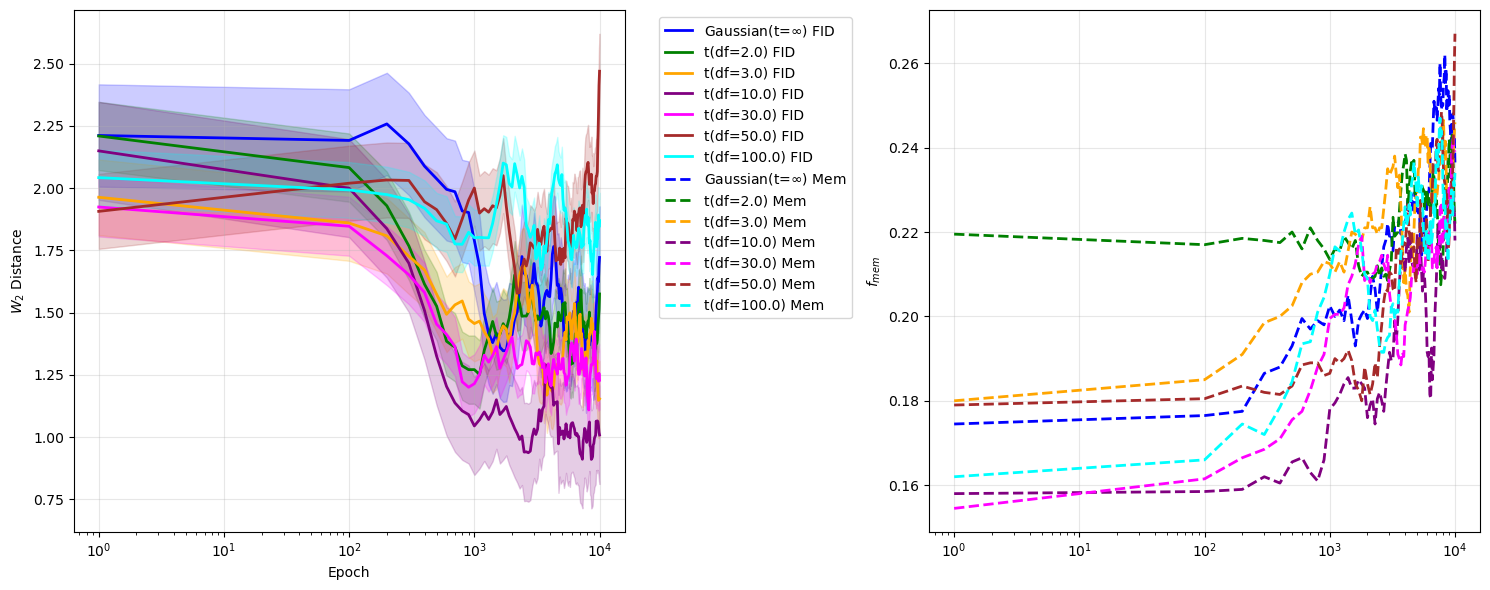

Plots saved to plots/spiral_heavytail/combined_analysis.png


In [47]:
# Analysis of Heavy-Tailed Experiment Results
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

def smooth_data(data, window_size=5):
    """Apply moving average smoothing to data"""
    if len(data) < window_size:
        return data
    return uniform_filter1d(data, size=window_size, mode='nearest')



def plot_heavytail_results(N=128, hidden=512, dfs=['inf', '2.0', '3.0', '10.0', '30.0', '50.0', '100.0'],
    colors=['blue', 'green', 'orange', 'purple', 'magenta', 'brown', 'cyan'],
    labels=['Gaussian(t=$\infty$)', 't(df=2.0)', 't(df=3.0)', 't(df=10.0)', 't(df=30.0)', 't(df=50.0)', 't(df=100.0)']):

    # Load data
    all_data = {}
    for df in dfs:
        data = np.load(f'logs/spiral_heavytail/metrics_N{N}_hidden{hidden}_df{df}.npz')
        all_data[df] = {
            'epoch': data['epoch'],
            'train_loss': data['train_loss'],
            'test_loss': data['test_loss'],
            'f_mem': data['f_mem'],
            'fid': data['fid']
        }

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: FID and Memorization vs Epoch
    for i, (df, data) in enumerate(all_data.items()):
        epochs = data['epoch']
        fid = data['fid']
        f_mem = data['f_mem']
        
        # Smooth the FID and memorization data
        fid_smooth = smooth_data(fid, window_size=10)
        f_mem_smooth = smooth_data(f_mem, window_size=10)


        # Plot FID with error bounds (using rolling std as proxy for variability)
        fid_std = np.std(fid_smooth) * 1.0  # Use 100% of std as error bound
        ax1.fill_between(epochs, fid_smooth - fid_std, fid_smooth + fid_std, alpha=0.2, color=colors[i])
        ax1.plot(epochs, fid_smooth, color=colors[i], linewidth=2, label=f'{labels[i]} FID')
        ax1.set_xscale('log')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('$W_2$ Distance', color='black')
        ax1.grid(True, alpha=0.3)

        # Plot memorization as dashed line on right axis
        ax2.plot(epochs, f_mem_smooth, color=colors[i], linewidth=2, linestyle='--', label=f'{labels[i]} Mem')

        ax2.set_xscale('log')
        ax2.set_ylabel('$f_{mem}$', color='black')
        ax2.grid(True, alpha=0.3)

        # Combine legends for left plot
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('plots/spiral_heavytail/combined_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_heavytail_results()
print('Plots saved to plots/spiral_heavytail/combined_analysis.png')

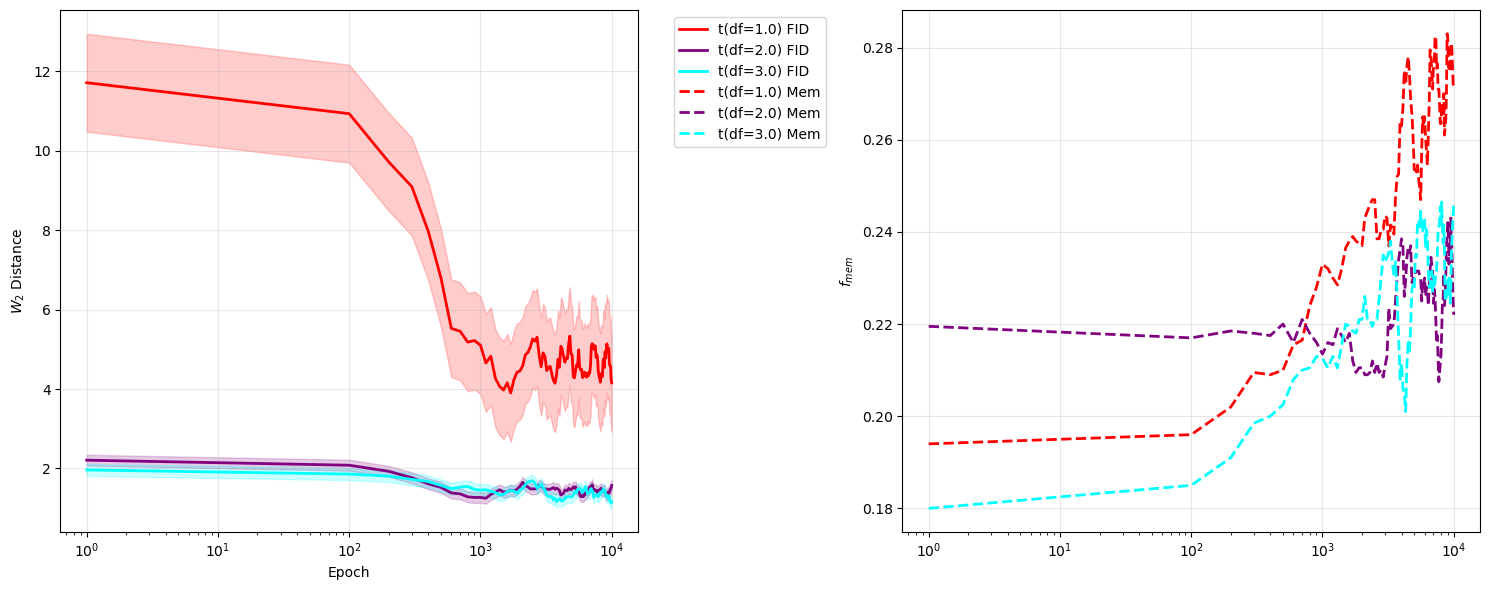

In [44]:
plot_heavytail_results(N=128, hidden=512, dfs=['1.0', '2.0', '3.0'], colors=['red', 'purple', 'cyan'], labels=['t(df=1.0)', 't(df=2.0)', 't(df=3.0)'])

## Experiment 3: Learning Curvature and Effect on Generalization

In [55]:
from scipy import stats
import os
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

log_dir = "logs/spiral_pow_v2"
plot_dir = "plots/spiral_pow_v2"
os.makedirs(log_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

# Experiment grid: fix N and hidden_dim, vary the degrees of freedom for the noise
experiments = [
    {'N': 128, 'hidden_dim': 512, 'df': 1.0},    # Cauchy distribution (infinite variance)
    {'N': 128, 'hidden_dim': 512, 'df': 2.0},    # Very heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 3.0},    # Heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 10.0},   # Moderately heavy-tailed
    {'N': 128, 'hidden_dim': 512, 'df': 100.0},  # Nearly Gaussian
    {'N': 128, 'hidden_dim': 512, 'df': np.inf}, # Gaussian (baseline)
]

num_epochs = int(1e4)
sample_size = 200

def power_schedule(t, k):
    return t ** k

def sine_schedule(t):
    return torch.sin(t * torch.pi / 2)

def flow_matching_loss_2d_time_warp(model, x0, k=2.0):
    batch_size = x0.shape[0]
    t = torch.rand(batch_size, 1, device=device)
    x1 = torch.randn_like(x0)
    xt = (1 - sine_schedule(t)) * x0 + sine_schedule(t) * x1
    target_v = x1 - x0
    pred_v = model(xt, t)
    return nn.MSELoss()(pred_v, target_v)

print("Starting Experiment 3: Allowing curvature with heavy-tailed noise effects on generalization-memorization trade-off")

# Main Experimental Loop for Experiment 3
for exp in experiments:
    N = exp['N']
    df = exp['df']
    
    # Generate spiral data with heavy-tailed noise
    theta = np.sqrt(np.random.rand(N)) * 2 * pi
    
    # Class A
    r_a = 2 * theta + pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    
    # Class B
    r_b = -2 * theta - pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    
    # Add heavy-tailed noise
    if np.isinf(df):
        # Standard Gaussian noise
        noise_a = np.random.randn(N, 2)
        noise_b = np.random.randn(N, 2)
        noise_label = "gaussian"
    else:
        # Student's t-distributed noise
        noise_a = stats.t.rvs(df=df, size=(N, 2))
        noise_b = stats.t.rvs(df=df, size=(N, 2))
        noise_label = f"t_{df}"
    
    x_a = data_a + noise_a
    x_b = data_b + noise_b
    
    # Combine and shuffle
    spiral_points = np.vstack([x_a, x_b]).astype(np.float32)
    train_points, test_points = train_test_split(spiral_points, test_size=0.25, random_state=42)
    
    # Normalize using training distribution
    train_tensor = torch.from_numpy(train_points).to(device)
    mean_spiral = train_tensor.mean(0, keepdim=True)
    std_spiral = train_tensor.std(0, unbiased=False, keepdim=True) + 1e-6
    train_norm = (train_tensor - mean_spiral) / std_spiral
    test_tensor = torch.from_numpy(test_points).to(device)
    test_norm = (test_tensor - mean_spiral) / std_spiral
    
    train_loader = DataLoader(train_norm, batch_size=len(train_norm), shuffle=True)
    
    model_spiral = FlowMatchingMLP(hidden_dim=exp['hidden_dim']).to(device)
    optimizer_spiral = optim.Adam(model_spiral.parameters(), lr=1e-3)
    
    epoch_metrics = []
    train_raw = train_points
    test_raw = test_points
    
    # Main training loop
    for epoch in tqdm(range(num_epochs)):
        model_spiral.train()
        total_loss = 0.0
        for x_batch in train_loader:
            x_batch = x_batch.to(device)
            loss = flow_matching_loss_2d_time_warp(model_spiral, x_batch, k=1.0)

            optimizer_spiral.zero_grad()
            loss.backward()
            optimizer_spiral.step()

            total_loss += loss.item()

        # record metrics every few epochs
        if (epoch + 1) % 100 == 0 or epoch == 0:
            # calculate training and test loss for the epoch
            avg_train_loss = total_loss / len(train_loader)
            test_loss = evaluate_loss(model_spiral, test_norm)

            # test sample generation
            samples_traj_norm = sample_spiral_flow(model_spiral, num_samples=sample_size, class_label=None)
            samples_norm = samples_traj_norm[-1]
            samples = (samples_norm * std_spiral + mean_spiral).cpu().numpy()
            initial_norm = samples_traj_norm[0]
            initial = (initial_norm * std_spiral + mean_spiral).cpu().numpy()

            # calculate memorization rate and FID (generalization metric) of generation samples
            memorized_count, total_samples = calculate_memorization(samples, train_raw)
            f_mem = memorized_count / total_samples
            fid = calculate_wasserstein_distance(samples, test_raw)

            epoch_metrics.append({
                'epoch': epoch + 1,
                'train_loss': avg_train_loss,
                'test_loss': test_loss,
                'f_mem': f_mem,
                'fid': fid,
            })

            log_path = os.path.join(log_dir, f"spiral_N{N}_hidden{exp['hidden_dim']}_df{exp['df']}.txt")
            msg = (
                f"Epoch {epoch+1}/{num_epochs} "
                f"| train_loss={avg_train_loss:.4f} "
                f"| test_loss={test_loss:.4f} "
                f"| f_mem={f_mem:.4f} "
                f"| fid={fid:.4f}\n"
            )
            with open(log_path, "a+") as log_file:
                log_file.write(msg)
    # end of training loop

    # save metrics
    metrics_path = os.path.join(log_dir, f"metrics_N{N}_hidden{exp['hidden_dim']}_df{exp['df']}.npz")
    np.savez(metrics_path, **{k: np.array([m[k] for m in epoch_metrics]) for k in epoch_metrics[0]})

    # save train and test loss plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot([m['epoch'] for m in epoch_metrics], [m['train_loss'] for m in epoch_metrics], label='Train Loss')
    plt.plot([m['epoch'] for m in epoch_metrics], [m['test_loss'] for m in epoch_metrics], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # save memorization and W2 plot
    ax1 = plt.subplot(1, 2, 2)
    ax2 = ax1.twinx()
    ax1.plot([m['epoch'] for m in epoch_metrics], [m['f_mem'] for m in epoch_metrics], label='Memorization', color='C0')
    ax2.plot([m['epoch'] for m in epoch_metrics], [m['fid'] for m in epoch_metrics], label='$W_2$ Distance', color='C1')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Memorization', color='C0')
    ax2.set_ylabel('$W_2$ Distance', color='C1')
    ax1.tick_params(axis='y', labelcolor='C0')
    ax2.tick_params(axis='y', labelcolor='C1')
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'metrics_N{N}_hidden{exp["hidden_dim"]}_df{exp["df"]}.png'))
    plt.close()

    # save generated samples plot
    plt.figure(figsize=(6, 6))
    plt.scatter(train_raw[:, 0], train_raw[:, 1], c='C0', s=8, alpha=0.4, label='Train Data')
    traj_np = samples_traj_norm.cpu().numpy()
    traj_np = traj_np * std_spiral.cpu().numpy() + mean_spiral.cpu().numpy()
    for i in range(traj_np.shape[1]):
        plt.plot(traj_np[:, i, 0], traj_np[:, i, 1], color='grey', alpha=0.2, linewidth=0.7)
    initial_points = traj_np[0]
    final_points = traj_np[-1]
    plt.scatter(initial_points[:, 0], initial_points[:, 1], c='grey', s=10, alpha=0.6, marker='x', label='Initial Samples')
    plt.scatter(final_points[:, 0], final_points[:, 1], c='C2', s=12, alpha=0.6, label='Generated Samples')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig(os.path.join(plot_dir, f'generated_N{N}_hidden{exp["hidden_dim"]}_df{exp["df"]}.png'))
    plt.close()

    # visualize vector field at multiple timestamps
    t_values = [0.2, 0.4, 0.6, 0.8, 1.0]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    data_range = (
        train_raw[:, 0].min() - 1.0,
        train_raw[:, 0].max() + 1.0,
        train_raw[:, 1].min() - 1.0,
        train_raw[:, 1].max() + 1.0,
    )
    
    for idx, t_vis in enumerate(t_values):
        xx, yy, vf = visualize_vector_field(model_spiral, mean_spiral, std_spiral, data_range, t=t_vis, class_label=None, grid_size=20)
        axes[idx].quiver(xx, yy, vf[..., 0], vf[..., 1], color='grey', alpha=0.8, scale=30, width=0.002)
        axes[idx].scatter(train_raw[:, 0], train_raw[:, 1], c='C0', s=8, alpha=0.4, label='Train Data')
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('y')
        axes[idx].axis('equal')
        axes[idx].set_title(f't={t_vis}')
        axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'vector_field_multi_N{N}_hidden{exp["hidden_dim"]}_df{exp["df"]}.png'))
    plt.close()

print("All experiments completed!")

Starting Experiment 3: Allowing curvature with heavy-tailed noise effects on generalization-memorization trade-off


100%|██████████| 10000/10000 [02:59<00:00, 55.71it/s]


All experiments completed!


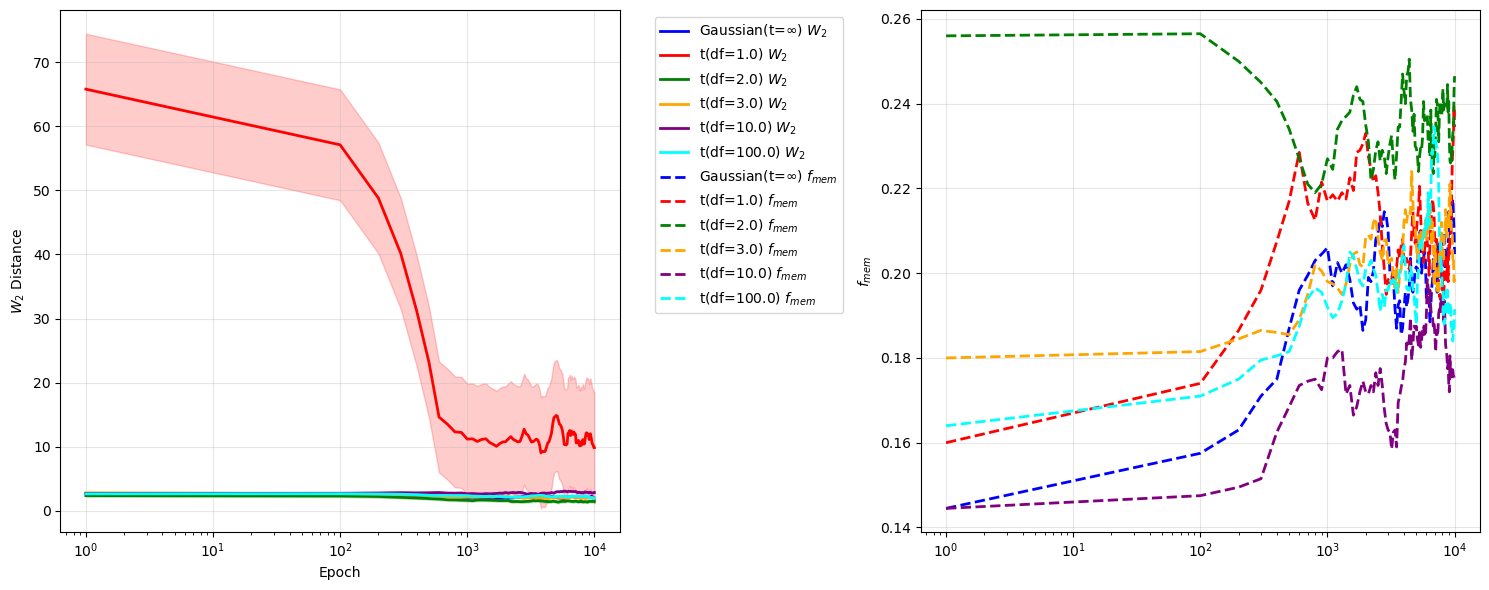

Plots saved


In [60]:
# Analysis of Heavy-Tailed Experiment Results
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

def smooth_data(data, window_size=5):
    """Apply moving average smoothing to data"""
    if len(data) < window_size:
        return data
    return uniform_filter1d(data, size=window_size, mode='nearest')



def plot_curvature_results(N=128, hidden=512, dfs=['inf', '1.0', '2.0', '3.0', '10.0', '100.0'],
    colors=['blue', 'red', 'green', 'orange', 'purple', 'cyan'],
    labels=['Gaussian(t=$\infty$)', 't(df=1.0)', 't(df=2.0)', 't(df=3.0)', 't(df=10.0)', 't(df=100.0)']):

    # Load data
    all_data = {}
    for df in dfs:
        data = np.load(f'logs/spiral_pow_v2/metrics_N{N}_hidden{hidden}_df{df}.npz')
        all_data[df] = {
            'epoch': data['epoch'],
            'train_loss': data['train_loss'],
            'test_loss': data['test_loss'],
            'f_mem': data['f_mem'],
            'W2': data['fid']
        }

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: FID and Memorization vs Epoch
    for i, (df, data) in enumerate(all_data.items()):
        epochs = data['epoch']
        W2 = data['W2']
        f_mem = data['f_mem']
        
        # Smooth the W2 and memorization data
        W2_smooth = smooth_data(W2, window_size=10)
        f_mem_smooth = smooth_data(f_mem, window_size=10)


        # Plot W2 with error bounds (using rolling std as proxy for variability)
        W2_std = np.std(W2_smooth) * 1.00  # Use 100% of std as error bound
        ax1.fill_between(epochs, W2_smooth - W2_std, W2_smooth + W2_std, alpha=0.2, color=colors[i])
        ax1.plot(epochs, W2_smooth, color=colors[i], linewidth=2, label=f'{labels[i]} $W_2$')
        ax1.set_xscale('log')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('$W_2$ Distance', color='black')
        ax1.grid(True, alpha=0.3)

        # Plot memorization as dashed line on right axis
        ax2.plot(epochs, f_mem_smooth, color=colors[i], linewidth=2, linestyle='--', label=f'{labels[i]} $f_{{mem}}$')

        ax2.set_xscale('log')
        ax2.set_ylabel('$f_{{mem}}$', color='black')
        ax2.grid(True, alpha=0.3)

        # Combine legends for left plot
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('plots/spiral_pow_v2/combined_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_curvature_results()
print('Plots saved')

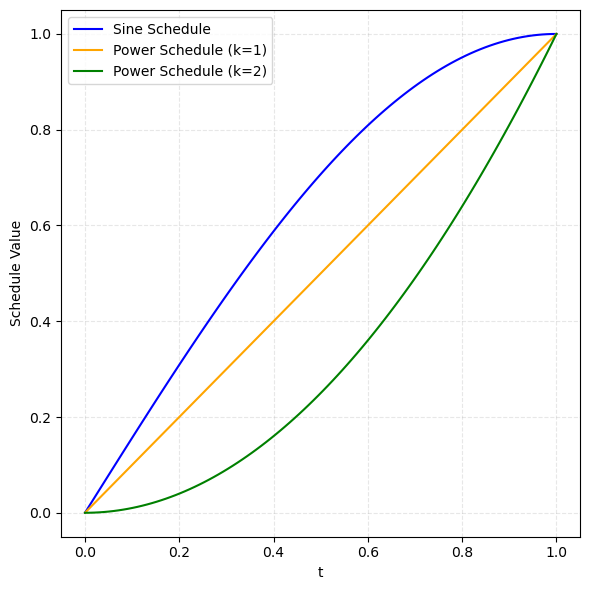

In [53]:
# plot of sine schedule vs power schedule vs linear schedule
t_values = torch.linspace(0, 1, 100)
sine_values = sine_schedule(t_values)
power_values_k1 = power_schedule(t_values, k=1.0)
power_values_k2 = power_schedule(t_values, k=2.0)
plt.figure(figsize=(6, 6))
plt.plot(t_values, sine_values, label='Sine Schedule', color='blue')
plt.plot(t_values, power_values_k1, label='Power Schedule (k=1)', color='orange')
plt.plot(t_values, power_values_k2, label='Power Schedule (k=2)', color='green')
plt.xlabel('t')
plt.ylabel('Schedule Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()